In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
from scipy.sparse import csr_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

In [4]:
print(os.getcwd())
this_path = os.getcwd()

C:\Users\Chenxi Zhou\Desktop\Neural Crest\SingleCrest\merscope\result\analysis\2025MAY\Tutorial_Github


In [7]:
## import count_matrix and meta data into h5ad file

adata = sq.read.vizgen(
    path=this_path,
    counts_file="cell_by_gene_filtered.csv",
    meta_file="cell_metadata_anno.csv",
    # transformation_file="micron_to_mosaic_pixel_transform.csv",
)

## filtered by selected gene

gene_df = pd.read_csv("selected_genes_for_cluster.csv")
gene_list = gene_df.iloc[:, 0].tolist()
adata = adata[:, adata.var_names.isin(gene_list)].copy()
print(adata.var_names.tolist())

adata.write_h5ad("MER02_R1_raw_subset.h5ad")

['ACTC1.L', 'CD44.L', 'CHRD.1.S', 'CLDN6.1.L', 'EYA1.L', 'FOXC2.L', 'HNF1B.L', 'KRT12.4.L', 'MYOD1.S', 'NOG.L', 'PAX3.S', 'PAX6.S', 'PITX1.L', 'POU5F3.1.L', 'SIX1.L', 'SNAI1.S', 'SOX10.L', 'SOX17A.S', 'SOX2.L', 'SOX3.S', 'SOX8.L', 'SOX9.S', 'TFAP2B.L', 'TP63.L', 'VENTX2.1.L', 'ZIC1.S', 'ZIC3.S', 'EYA2.S']


In [10]:
## filterout background
## make counts <= 1 to 0

adata.layers["raw_counts"]=adata.X.copy()
adata.X = adata.layers["raw_counts"].copy()
adata.layers["raw_counts_bg_removeby1"] =adata.layers["raw_counts"].copy()
adata.X = adata.layers["raw_counts_bg_removeby1"].copy() 

from scipy import sparse

print("Non-zero count before:", adata.X.nnz)
adata.X.data[adata.X.data <= 1] = 0
adata.X.eliminate_zeros()
print("Non-zero count after:", adata.X.nnz)

adata.layers["raw_counts_bg_removeby1"] = adata.X

adata.to_df()




Non-zero count before: 263852
Non-zero count after: 162756


,ACTC1.L,CD44.L,CHRD.1.S,CLDN6.1.L,EYA1.L,FOXC2.L,HNF1B.L,KRT12.4.L,MYOD1.S,NOG.L,...,SOX2.L,SOX3.S,SOX8.L,SOX9.S,TFAP2B.L,TP63.L,VENTX2.1.L,ZIC1.S,ZIC3.S,EYA2.S
2685806100002100001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,634.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100002100002,0.0,2.0,0.0,0.0,9.0,0.0,0.0,111.0,0.0,2.0,...,0.0,26.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100002100003,0.0,0.0,0.0,0.0,3.0,0.0,0.0,357.0,0.0,0.0,...,2.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100002100004,2.0,0.0,0.0,0.0,4.0,0.0,0.0,120.0,0.0,0.0,...,0.0,11.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0
2685806100002100005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,108.0,0.0,0.0,...,2.0,13.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2685806100568100075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,216.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
2685806100568100076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100568100077,0.0,0.0,0.0,0.0,3.0,0.0,0.0,292.0,0.0,0.0,...,0.0,4.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0
2685806100568100078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,111.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
adata

AnnData object with n_obs × n_vars = 22328 × 28
    obs: 'crop', 'stage', 'embryo_ID', 'section_level', 'uniqueID', 'fov', 'volume', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity'
    uns: 'spatial'
    obsm: 'blank_genes', 'spatial'
    layers: 'raw_counts', 'raw_counts_bg_removeby1'

C:\Users\Chenxi Zhou\anaconda3\envs\scanpy\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Chenxi Zhou\anaconda3\envs\scanpy\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Chenxi Zhou\anaconda3\envs\scanpy\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Chenxi Zhou\anaconda3\envs\scanpy\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future

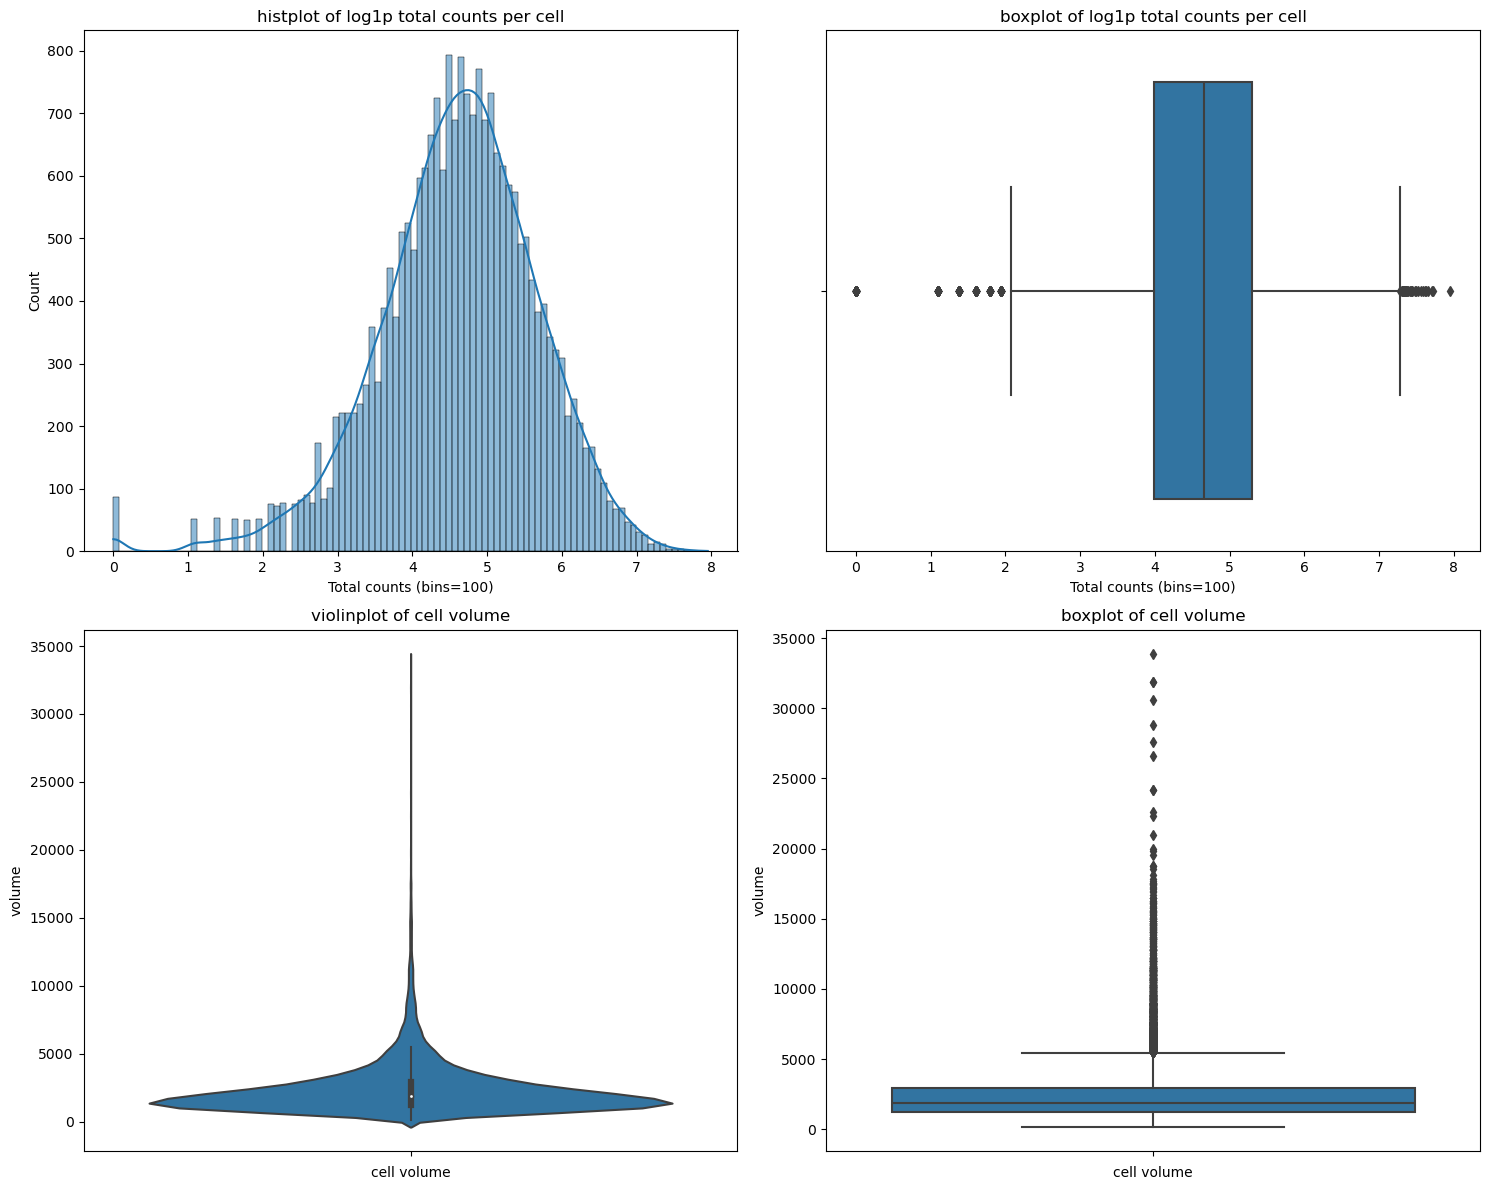

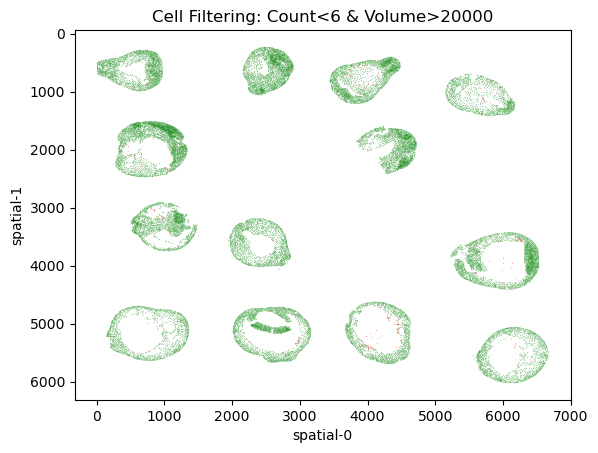

In [25]:
## Qaulity control of the data based on count and volume distribution

adata.X = adata.layers["raw_counts_bg_removeby1"]
sc.pp.calculate_qc_metrics(adata,percent_top=(1,5,10,15), inplace=True)


fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(
    data=adata.obs,
    x="log1p_total_counts",
    kde=True,
    ax=axes[0,0],
    bins=100, 
)
axes[0,0].set_title("histplot of log1p total counts per cell")
axes[0,0].set_xlabel("Total counts (bins=100)")
#ax1.axvline(x=3, color="red", linestyle="--")


sns.boxplot(
    data=adata.obs,
    x="log1p_total_counts",
    ax=axes[0,1],
)
axes[0,1].set_title("boxplot of log1p total counts per cell")
axes[0,1].set_xlabel("Total counts (bins=100)")


sns.violinplot(
    data=adata.obs,
    y="volume",
    ax=axes[1,0],
)
axes[1,0].set_title("violinplot of cell volume")
axes[1,0].set_xlabel("cell volume")


sns.boxplot(
    data=adata.obs,
    y="volume",
    ax=axes[1,1],
)
axes[1,1].set_title("boxplot of cell volume")
axes[1,1].set_xlabel("cell volume")


plt.tight_layout()
plt.savefig("qc_metrics_combined.png", dpi=300)
plt.show()


## draw the binary plot of filtered cells 

adata_df = sc.get.obs_df(adata,keys=["total_counts", "volume", "log1p_total_counts"], obsm_keys=[("spatial",0),("spatial",1)])

count_threshold = 6  ## set the count cutoff threshold
volume_threshold = 20000  ## set the volume cutoff threshold

# kept cells color: green
adata_df["dot_color"] = "green"  

# only count_threshold < 6: red
adata_df.loc[adata_df["total_counts"] < count_threshold, "dot_color"] = "red"

# only volume_threshold > 20000: blue  
adata_df.loc[adata_df["volume"] > volume_threshold, "dot_color"] = "blue"

# both count_threshold < 6 and volume_threshold > 20000: orange
adata_df.loc[(adata_df["total_counts"] < count_threshold) & (adata_df["volume"] > volume_threshold), "dot_color"] = "orange"

fig = adata_df.plot.scatter(x="spatial-0", y="spatial-1", c=adata_df["dot_color"], s=1, marker='.', linewidths=0)
fig.invert_yaxis()
plt.title(f"Cell Filtering: Count<{count_threshold} & Volume>{volume_threshold}")
plt.savefig(f"cell_filtering_count{count_threshold}_volume{volume_threshold}.png", dpi=300)

In [33]:
## filtering low quality cells

# filtered out by volume
adata.obs["volume_filter"]=np.where(adata.obs["volume"] <= 20000, "keep", "remove")
adata_filtered = adata[adata.obs["volume_filter"] == "keep"].copy()
print(adata_filtered.obs["volume_filter"].unique())

# filtered out by minimum total_counts
sc.pp.filter_cells(adata_filtered, min_counts=6)

adata_filtered.write_h5ad("MER02_R1_filtered_subset.h5ad")



['keep']


In [34]:
adata_filtered

AnnData object with n_obs × n_vars = 22023 × 28
    obs: 'crop', 'stage', 'embryo_ID', 'section_level', 'uniqueID', 'fov', 'volume', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_1_genes', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'volume_filter', 'n_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'blank_genes', 'spatial'
    layers: 'raw_counts', 'raw_counts_bg_removeby1'